In [2]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

In [3]:
SEED: int = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Data pipeline

In [4]:
from data_pipeline import get_dataloaders, plot_dataset_distribution

train_loader, val_loader, test_loader, input_dim, class_mapping = get_dataloaders(
    data_dir="../data",
    is_binary=True,
    batch_size=32
)
print(f"Wymiar wejściowy modelu: {input_dim}")

Loading cached dataset and mapping...
Wymiar wejściowy modelu: 77


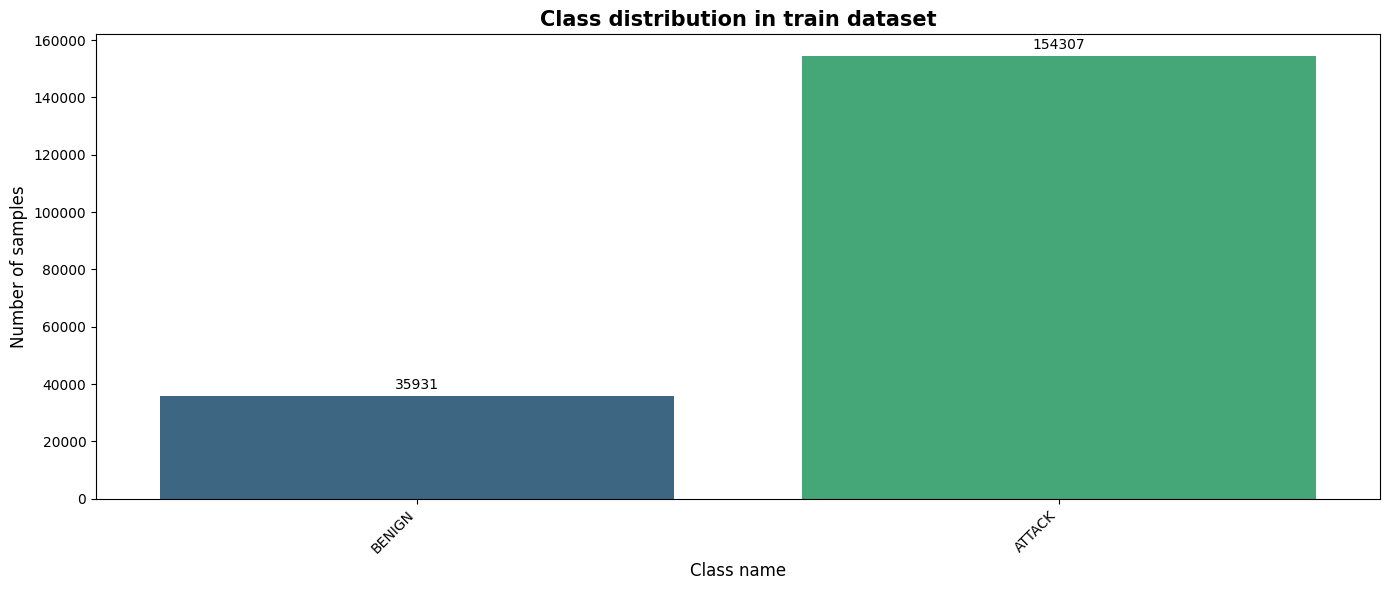

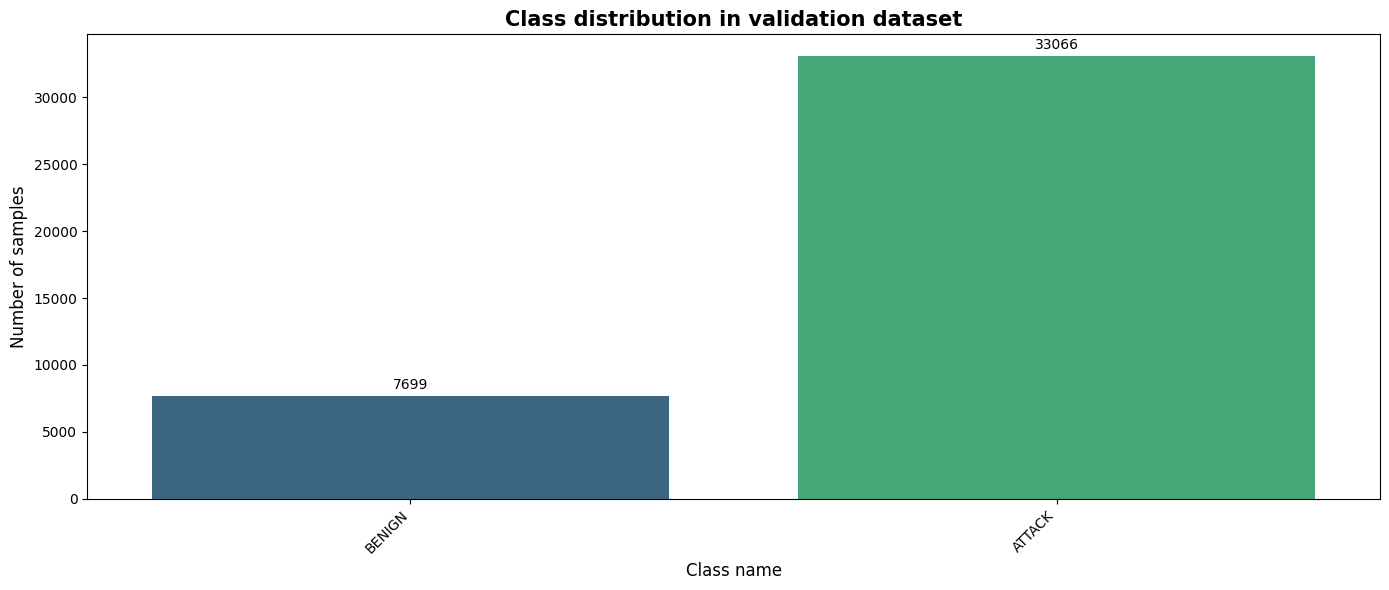

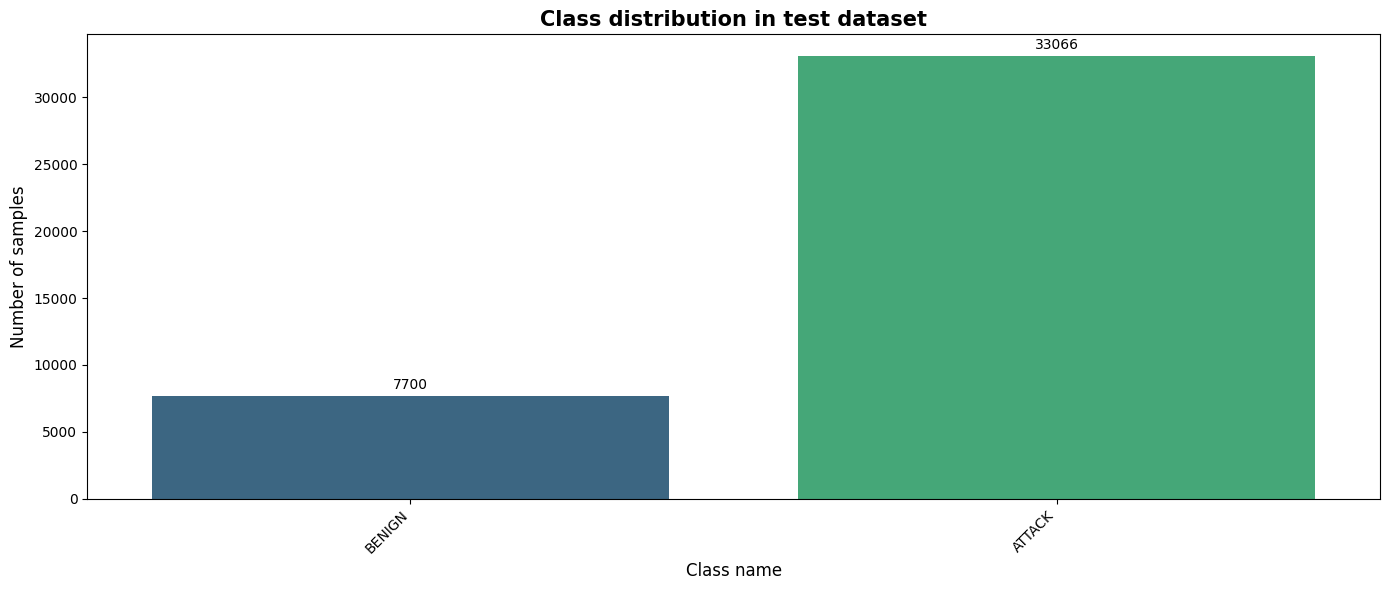

In [5]:
train_dataset, valid_dataset, test_dataset = train_loader.dataset, val_loader.dataset, test_loader.dataset

plot_dataset_distribution(train_dataset.y, class_mapping, dataset_name="train dataset")
plot_dataset_distribution(valid_dataset.y, class_mapping, dataset_name="validation dataset")
plot_dataset_distribution(test_dataset.y, class_mapping, dataset_name="test dataset")

# Modele

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy

print(f"Dostępność GPU: {torch.cuda.is_available()}")

Dostępność GPU: True


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu" )
device

device(type='cuda')

## Klasy modeli

In [20]:
class DDoSNetEncoder(nn.Module):
    def __init__(self, input_dim):
        super(DDoSNetEncoder, self).__init__()
        self.rnn1 = nn.RNN(input_size=input_dim, hidden_size=64, batch_first=True, nonlinearity='relu')
        self.rnn2 = nn.RNN(input_size=64, hidden_size=32, batch_first=True, nonlinearity='relu')
        self.rnn3 = nn.RNN(input_size=32, hidden_size=16, batch_first=True, nonlinearity='relu')
        self.rnn4 = nn.RNN(input_size=16, hidden_size=8, batch_first=True, nonlinearity='relu')

    def forward(self, x):
        x, _ = self.rnn1(x)
        x, _ = self.rnn2(x)
        x, _ = self.rnn3(x)
        x, _ = self.rnn4(x)
        return x

In [21]:
class DDoSNetDecoder(nn.Module):
    def __init__(self, output_dim):
        super(DDoSNetDecoder, self).__init__()
        self.rnn1 = nn.RNN(input_size=8, hidden_size=8, batch_first=True, nonlinearity='relu')
        self.rnn2 = nn.RNN(input_size=8, hidden_size=16, batch_first=True, nonlinearity='relu')
        self.rnn3 = nn.RNN(input_size=16, hidden_size=32, batch_first=True, nonlinearity='relu')
        self.rnn4 = nn.RNN(input_size=32, hidden_size=64, batch_first=True, nonlinearity='relu')

        self.reconstruction_layer = nn.Linear(64, output_dim)

    def forward(self, x):
        x, _ = self.rnn1(x)
        x, _ = self.rnn2(x)
        x, _ = self.rnn3(x)
        x, _ = self.rnn4(x)

        reconstructed = self.reconstruction_layer(x)
        return reconstructed

In [22]:
class DDoSNetReconstruction(nn.Module):
    def __init__(self, input_dim, encoder=None, decoder=None):
        super(DDoSNetReconstruction, self).__init__()

        self.encoder = encoder if encoder is not None else DDoSNetEncoder(input_dim)
        self.decoder = decoder if decoder is not None else DDoSNetDecoder(input_dim)

    def forward(self, x):
        encoded_sequence = self.encoder(x)
        reconstructed_sequence = self.decoder(encoded_sequence)

        return reconstructed_sequence

In [ ]:

class DDoSNetClassifier(nn.Module):
    def __init__(self, input_dim, encoder=None, decoder=None):
        super(DDoSNetClassifier, self).__init__()

        self.encoder = encoder if encoder is not None else DDoSNetEncoder(input_dim)
        self.decoder = decoder if decoder is not None else DDoSNetDecoder(input_dim)

        self.classifier = nn.Linear(input_dim, 2)

    def forward(self, x):
        encoded = self.encoder(x)
        reconstructed = self.decoder(encoded)

        last_step_reconstructed = reconstructed[:, -1, :]
        logits = self.classifier(last_step_reconstructed)

        return logits

## Trenowanie

### Fnkcje pomocnicze

In [ ]:
def finetune_classifier(model, train_loader, val_loader, device, epochs=50, lr=0.0001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())

    train_losses = [None]*epochs
    val_losses = [None]*epochs
    train_acc = [None]*epochs
    val_acc = [None]*epochs

    model.to(device)

    epoch_bar = tqdm(range(epochs), desc="Trening modelu")
    for epoch in epoch_bar:
        model.train()
        train_loss, train_correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).long()
            if inputs.dim() == 2:
                inputs = inputs.unsqueeze(1)

            optimizer.zero_grad()

            logits = model(inputs)

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        epoch_train_loss = train_loss / total
        epoch_train_acc = train_correct / total
        train_losses[epoch] = epoch_train_loss
        train_acc[epoch] = epoch_train_acc

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).long()
                if inputs.dim() == 2:
                    inputs = inputs.unsqueeze(1)

                logits = model(inputs)
                loss = criterion(logits, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(logits.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total
        val_losses[epoch] = epoch_val_loss
        val_acc[epoch] = epoch_val_acc

        epoch_bar.set_postfix({
            'train_acc': f"{train_acc[epoch]:.4f}",
            'val_acc': f"{val_acc[epoch]:.4f}"
        })

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_weights)
    return model, (train_losses, val_losses), (train_acc, val_acc)


### Testowanie parametrów

In [31]:
lrs = [0.1, 0.01, 0.001, 0.0001, 0.00005]

In [ ]:
results = []
best_val_acc = 0.0
best_model_weights = None
best_lr = None

In [ ]:
loaded_reconstruction_model = DDoSNetReconstruction(input_dim=input_dim)
saved_model_path = "../saved_models/best_autoencoder_full.pth"

loaded_reconstruction_model.load_state_dict(
    torch.load(saved_model_path, map_location=device)
)

pretrained_encoder = loaded_reconstruction_model.encoder
pretrained_decoder = loaded_reconstruction_model.decoder

In [ ]:
for i, lr in enumerate(lrs):
    print(f"--- Trening {i+1}/{len(lrs)} | Ustawienia: {lr=} ---")

    current_model = DDoSNetClassifier(
        input_dim=input_dim,
        encoder=copy.deepcopy(pretrained_encoder),
        decoder=copy.deepcopy(pretrained_decoder)
    ).to(device)

    trained_model, (train_losses, val_losses), (train_acc, val_acc) = finetune_classifier(
        model=current_model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        epochs=10,
        lr=lr
    )

    current_best_acc = max(val_acc) if len(val_acc) > 0 else 0
    current_min_loss = min(val_losses) if len(val_losses) > 0 else 0

    results.append({
        'lr': lr,
        'best_val_loss': current_min_loss,
        'best_val_acc': current_best_acc
    })

    if current_best_acc > best_val_acc:
        best_val_acc = current_best_acc
        best_lr = lr
        best_model_weights = copy.deepcopy(trained_model.state_dict())

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='best_val_acc', ascending=False).reset_index(drop=True)

print("\n================ PODSUMOWANIE WYNIKÓW ================")
print(results_df.to_string())
print("======================================================")

print(f"\nNajlepszy lr to: {best_lr}")
print(f"Uzyskana dokładność na zbiorze walidacyjnym: {best_val_acc:.4f}")

--- Trening 1/5 | Ustawienia: lr=0.1 ---


Trening modelu:   0%|          | 0/10 [00:00<?, ?it/s]

Trening modelu: 100%|██████████| 10/10 [04:20<00:00, 26.05s/it, train_acc=0.8096, val_acc=0.8111]


--- Trening 2/5 | Ustawienia: lr=0.01 ---


Trening modelu: 100%|██████████| 10/10 [04:24<00:00, 26.44s/it, train_acc=0.9520, val_acc=0.9508]


...

--- Trening 4/5 | Ustawienia: lr=0.0001 ---


Trening modelu: 100%|██████████| 10/10 [07:40<00:00, 46.01s/it, train_acc=0.9973, val_acc=0.9972]


--- Trening 5/5 | Ustawienia: lr=5e-05 ---


Trening modelu: 100%|██████████| 10/10 [06:38<00:00, 39.85s/it, train_acc=0.9969, val_acc=0.9969]


================ PODSUMOWANIE WYNIKÓW ================
        lr  best_val_loss  best_val_acc
0  0.00100       0.009432      0.997571
1  0.00010       0.011473      0.997302
2  0.00005       0.012653      0.996958
3  0.01000       0.015648      0.996860
4  0.01000       0.484570      0.811137
5  0.10000       0.484658      0.811137
6  0.10000       0.484791      0.811137
7  0.00005       0.484570      0.811137
8  0.00010       0.484570      0.811137
9  0.00100       0.484573      0.811137

Najlepszy lr to: 0.001
Uzyskana dokładność na zbiorze walidacyjnym: 0.9976
